In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install tensorflow opencv-python


[notice] A new release of pip is available: 24.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, BatchNormalization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, recall_score, precision_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import pandas as pd
import os
import cv2
from sklearn.utils import shuffle

In [11]:
videos = []
classes = []

path ="../videos"
normal= os.path.join(path, "normal")
suspicious = os.path.join(path, "robbery")

videos = []
labelsDict = {0: "Normal", 1: "Suspicious"}
labels = []

for video in os.listdir(normal):
    videos.append(os.path.join(normal, video))
    labels.append(0)

for video in os.listdir(suspicious):
    videos.append(os.path.join(suspicious, video))
    labels.append(1)

df = pd.DataFrame({"videos": videos, "classes": labels})
df['videos'] = videos
df['classes'] = labels

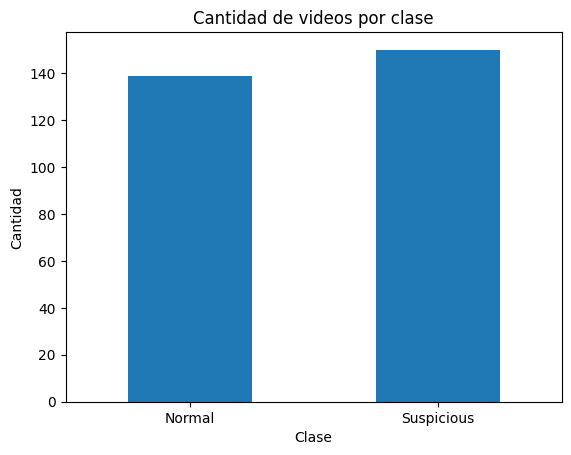

In [17]:
counts = df["classes"].value_counts().sort_index()

# Graficar
counts.plot(kind="bar")
plt.xticks(ticks=[0, 1], labels=["Normal", "Suspicious"], rotation=0)
plt.title("Cantidad de videos por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

In [18]:
# Parámetros
IMG_SIZE = 112  # Tamaño del frame
SEQUENCE_LENGTH = 100  # Número de frames por video

# Función para cargar y procesar videos
def load_video(video_path, max_frames=SEQUENCE_LENGTH):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frames.append(frame)
    cap.release()

    # Si el video tiene menos frames, repite los últimos
    while len(frames) < max_frames:
        frames.append(frames[-1])

    return np.array(frames, dtype=np.float32) / 255.0  # Normaliza los valores

In [19]:
# normalizar todos los videos
df["videos"] = df["videos"].apply(load_video)

# Dividir el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    df["videos"], df["classes"], test_size=0.2, random_state=42, stratify=df["classes"]
)


In [20]:
#Contar la cantidad de videos por clase
unique, counts = np.unique(y_train, return_counts=True)
print(f"Videos de entrenamiento por clase: {dict(zip(unique, counts))}")

unique, counts = np.unique(y_test, return_counts=True)
print(f"Videos de validación por clase: {dict(zip(unique, counts))}")

Videos de entrenamiento por clase: {0: 111, 1: 120}
Videos de validación por clase: {0: 28, 1: 30}


In [21]:
# Crear un modelo 3D CNN
def create_3d_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv3D(32, kernel_size=(3, 3, 3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        tf.keras.layers.Conv3D(64, kernel_size=(3, 3, 3), activation='relu'),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        tf.keras.layers.Conv3D(128, kernel_size=(3, 3, 3), activation='relu'),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Crear el modelo
input_shape = (SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)
num_classes = len(np.unique(labels))
model = create_3d_cnn(input_shape, num_classes)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 98, 110, 110,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 49, 55, 55, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 47, 53, 53, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 23, 26, 26, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 21, 24, 24,     │       221,312 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 10, 12, 12,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 184320)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,593,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,872,642 (91.07 MB)

 Trainable params: 23,872,642 (91.07 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#earlyStopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)

# Convertir la Serie de Pandas en un array de NumPy
X_train = np.array(X_train.tolist())
X_test = np.array(X_test.tolist())

# Entrenamiento del modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=1,
    batch_size=16,
    #callbacks=[earlyStopping]
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 141s 7s/step - accuracy: 0.5398 - loss: 7.0460 - val_accuracy: 0.6897 - val_loss: 0.6798


In [23]:
# Evaluar el modelo
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Pérdida: {loss}, Precisión: {accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.7098 - loss: 0.6788
Pérdida: 0.6798484921455383, Precisión: 0.6896551847457886


2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step


              precision    recall  f1-score   support

           0       0.67      0.71      0.69        28
           1       0.71      0.67      0.69        30

    accuracy                           0.69        58
   macro avg       0.69      0.69      0.69        58
weighted avg       0.69      0.69      0.69        58



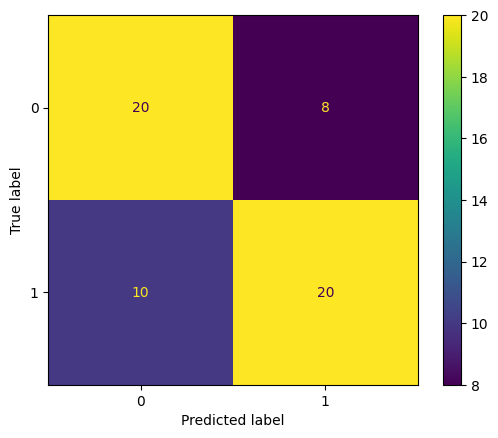

In [24]:
# reporte de clasificación
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(labels))
disp.plot()

# Guardar el modelo
model.save('modelSuspicious.h5')